Notebook 04 — Intrinsic Embedding Evaluation

In [133]:
!pip install -q gensim

In [134]:
import os
import random
import warnings
import zipfile

import numpy as np
import pandas as pd

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [135]:
# ============================================
# Cell 3: Start Timer
# ============================================

import time

start_time = time.time()

In [136]:
RESULTS_DIR = "/content/intrinsic_evaluation_results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Results folder created.")

Results folder created.


In [137]:
ZIP_PATH = "/content/punjabi_word2vec_models.zip"

MODELS_DIR = "/content/models"

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as archive:

    archive.extractall(
        MODELS_DIR
    )

print("Models extracted.")
print(os.listdir(MODELS_DIR))

Models extracted.
['gurmukhi_skipgram.model', 'shahmukhi_skipgram.model', 'gurmukhi_cbow_word2vec.model', 'shahmukhi_cbow.model', 'gurmukhi_cbow.model']


In [138]:
GURMUKHI_CBOW = f"{MODELS_DIR}/gurmukhi_cbow.model"

GURMUKHI_SKIPGRAM = f"{MODELS_DIR}/gurmukhi_skipgram.model"

SHAHMUKHI_CBOW = f"{MODELS_DIR}/shahmukhi_cbow.model"

SHAHMUKHI_SKIPGRAM = f"{MODELS_DIR}/shahmukhi_skipgram.model"


gurmukhi_cbow = Word2Vec.load(
    GURMUKHI_CBOW
)

gurmukhi_skipgram = Word2Vec.load(
    GURMUKHI_SKIPGRAM
)

shahmukhi_cbow = Word2Vec.load(
    SHAHMUKHI_CBOW
)

shahmukhi_skipgram = Word2Vec.load(
    SHAHMUKHI_SKIPGRAM
)

print("✅ All models loaded successfully.")

✅ All models loaded successfully.


In [139]:
# ============================================
# Cell 6: Model Registry
# ============================================

models = {
    "Gurmukhi CBOW": gurmukhi_cbow,
    "Gurmukhi Skip-gram": gurmukhi_skipgram,
    "Shahmukhi CBOW": shahmukhi_cbow,
    "Shahmukhi Skip-gram": shahmukhi_skipgram
}

for model_name, model in models.items():

    print(
        model_name,
        "| Vocabulary:",
        len(model.wv),
        "| Dimensions:",
        model.vector_size
    )

Gurmukhi CBOW | Vocabulary: 6349 | Dimensions: 200
Gurmukhi Skip-gram | Vocabulary: 5205 | Dimensions: 200
Shahmukhi CBOW | Vocabulary: 6748 | Dimensions: 200
Shahmukhi Skip-gram | Vocabulary: 6748 | Dimensions: 200


In [140]:
# ============================================
# Cell 7: Model Summary Table
# ============================================

model_summary = pd.DataFrame([
    {
        "Model": model_name,
        "Script": (
            "Gurmukhi"
            if model_name.startswith("Gurmukhi")
            else "Shahmukhi"
        ),
        "Architecture": (
            "CBOW"
            if "CBOW" in model_name
            else "Skip-gram"
        ),
        "Vocabulary Size": len(model.wv),
        "Vector Dimensions": model.vector_size,
        "Window Size": model.window,
        "Minimum Count": model.min_count,
        "Epochs": model.epochs
    }
    for model_name, model in models.items()
])

model_summary

,Model,Script,Architecture,Vocabulary Size,Vector Dimensions,Window Size,Minimum Count,Epochs
0,Gurmukhi CBOW,Gurmukhi,CBOW,6349,200,5,5,15
1,Gurmukhi Skip-gram,Gurmukhi,Skip-gram,5205,200,5,5,15
2,Shahmukhi CBOW,Shahmukhi,CBOW,6748,200,5,5,15
3,Shahmukhi Skip-gram,Shahmukhi,Skip-gram,6748,200,5,5,15


In [141]:
# ============================================
# Cell 8: Save Model Summary
# ============================================

model_summary.to_csv(
    f"{RESULTS_DIR}/model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Model summary saved.")

✅ Model summary saved.


In [142]:
# ============================================
# Cell 10: Evaluation Vocabulary
# ============================================

evaluation_words = {
    "Gurmukhi": [
        "ਭਾਰਤ",
        "ਪਾਕਿਸਤਾਨ",
        "ਪੰਜਾਬ",
        "ਗੁਰੂ",
        "ਨਾਨਕ",
        "ਸਿੱਖ",
        "ਲਾਹੌਰ",
        "ਮੁੰਬਈ"
    ],

    "Shahmukhi": [
        "بھارت",
        "پاکستان",
        "پںجاب",      # use the spelling that exists in your corpus
        "گرو",
        "نانک",
        "سکھ",
        "لاہور",
        "مںبی"        # use the spelling that exists in your corpus
    ]
}

print("✅ Evaluation vocabulary created.")

✅ Evaluation vocabulary created.


In [143]:
# ============================================
# Cell 10: Evaluation Vocabulary
# ============================================

evaluation_words = {
    "Gurmukhi": [
        "ਭਾਰਤ",
        "ਪਾਕਿਸਤਾਨ",
        "ਪੰਜਾਬ",
        "ਗੁਰੂ",
        "ਨਾਨਕ",
        "ਸਿੱਖ",
        "ਲਾਹੌਰ",
        "ਮੁੰਬਈ"
    ],

    "Shahmukhi": [
        "بھارت",
        "پاکستان",
        "پںجاب",      # spelling found in your corpus
        "گرو",
        "نانک",
        "سکھ",
        "لاہور",
        "مںبی"        # spelling found in your corpus
    ]
}

print("✅ Evaluation vocabulary created.")

✅ Evaluation vocabulary created.


In [144]:
# ============================================
# Cell 11: Vocabulary Coverage
# ============================================

coverage = []

for script, words in evaluation_words.items():

    if script == "Gurmukhi":
        current_models = {
            "CBOW": models["Gurmukhi CBOW"],
            "Skip-gram": models["Gurmukhi Skip-gram"]
        }
    else:
        current_models = {
            "CBOW": models["Shahmukhi CBOW"],
            "Skip-gram": models["Shahmukhi Skip-gram"]
        }

    for word in words:

        row = {
            "Script": script,
            "Word": word
        }

        for model_name, model in current_models.items():
            row[model_name] = word in model.wv

        coverage.append(row)

coverage_df = pd.DataFrame(coverage)

coverage_df

,Script,Word,CBOW,Skip-gram
0,Gurmukhi,ਭਾਰਤ,True,True
1,Gurmukhi,ਪਾਕਿਸਤਾਨ,True,True
2,Gurmukhi,ਪੰਜਾਬ,True,True
3,Gurmukhi,ਗੁਰੂ,True,True
4,Gurmukhi,ਨਾਨਕ,True,True
5,Gurmukhi,ਸਿੱਖ,True,True
6,Gurmukhi,ਲਾਹੌਰ,True,True
7,Gurmukhi,ਮੁੰਬਈ,True,True
8,Shahmukhi,بھارت,True,True
9,Shahmukhi,پاکستان,True,True


In [145]:
# ============================================
# Cell 12: Save Vocabulary Coverage
# ============================================

coverage_df.to_csv(
    f"{RESULTS_DIR}/vocabulary_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Vocabulary coverage saved.")

✅ Vocabulary coverage saved.


In [146]:
# ============================================
# Cell 13: Semantic Similarity Word Pairs
# ============================================

similarity_pairs = {
    "Gurmukhi": [
        ("ਭਾਰਤ", "ਪਾਕਿਸਤਾਨ"),
        ("ਪੰਜਾਬ", "ਲਾਹੌਰ"),
        ("ਗੁਰੂ", "ਨਾਨਕ"),
        ("ਸਿੱਖ", "ਗੁਰੂ"),
        ("ਮੁੰਬਈ", "ਭਾਰਤ")
    ],

    "Shahmukhi": [
        ("بھارت", "پاکستان"),
        ("پںجاب", "لاہور"),
        ("گرو", "نانک"),
        ("سکھ", "گرو"),
        ("مںبی", "بھارت")
    ]
}

print("✅ Similarity pairs created.")

✅ Similarity pairs created.


In [147]:
# ============================================
# Cell 14: Cosine Similarity Evaluation
# ============================================

cosine_results = []

for script, pairs in similarity_pairs.items():

    if script == "Gurmukhi":
        current_models = {
            "CBOW": models["Gurmukhi CBOW"],
            "Skip-gram": models["Gurmukhi Skip-gram"]
        }
    else:
        current_models = {
            "CBOW": models["Shahmukhi CBOW"],
            "Skip-gram": models["Shahmukhi Skip-gram"]
        }

    for model_name, model in current_models.items():

        for word1, word2 in pairs:

            if word1 in model.wv and word2 in model.wv:

                similarity = model.wv.similarity(word1, word2)

            else:

                similarity = np.nan

            cosine_results.append({
                "Script": script,
                "Model": model_name,
                "Word 1": word1,
                "Word 2": word2,
                "Cosine Similarity": similarity
            })

cosine_df = pd.DataFrame(cosine_results)

cosine_df

,Script,Model,Word 1,Word 2,Cosine Similarity
0,Gurmukhi,CBOW,ਭਾਰਤ,ਪਾਕਿਸਤਾਨ,0.642050
1,Gurmukhi,CBOW,ਪੰਜਾਬ,ਲਾਹੌਰ,0.492094
2,Gurmukhi,CBOW,ਗੁਰੂ,ਨਾਨਕ,0.414431
3,Gurmukhi,CBOW,ਸਿੱਖ,ਗੁਰੂ,0.279486
4,Gurmukhi,CBOW,ਮੁੰਬਈ,ਭਾਰਤ,0.444377
5,Gurmukhi,Skip-gram,ਭਾਰਤ,ਪਾਕਿਸਤਾਨ,0.481907
6,Gurmukhi,Skip-gram,ਪੰਜਾਬ,ਲਾਹੌਰ,0.447190
7,Gurmukhi,Skip-gram,ਗੁਰੂ,ਨਾਨਕ,0.401623
8,Gurmukhi,Skip-gram,ਸਿੱਖ,ਗੁਰੂ,0.371963
9,Gurmukhi,Skip-gram,ਮੁੰਬਈ,ਭਾਰਤ,0.375166


In [148]:
# ============================================
# Cell 15: Save Cosine Similarity Results
# ============================================

cosine_df.to_csv(
    f"{RESULTS_DIR}/cosine_similarity.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Cosine similarity results saved.")

✅ Cosine similarity results saved.


In [149]:
# ============================================
# Cell 16: Average Cosine Similarity per Model
# ============================================

cosine_summary = (
    cosine_df
    .groupby(
        ["Script", "Model"],
        as_index=False
    )
    .agg(
        Evaluated_Pairs=("Cosine Similarity", "count"),
        Mean_Cosine_Similarity=("Cosine Similarity", "mean"),
        Standard_Deviation=("Cosine Similarity", "std"),
        Minimum_Similarity=("Cosine Similarity", "min"),
        Maximum_Similarity=("Cosine Similarity", "max")
    )
)

numeric_columns = [
    "Mean_Cosine_Similarity",
    "Standard_Deviation",
    "Minimum_Similarity",
    "Maximum_Similarity"
]

cosine_summary[numeric_columns] = (
    cosine_summary[numeric_columns].round(4)
)

cosine_summary

,Script,Model,Evaluated_Pairs,Mean_Cosine_Similarity,Standard_Deviation,Minimum_Similarity,Maximum_Similarity
0,Gurmukhi,CBOW,5,0.4545,0.1313,0.2795,0.6420
1,Gurmukhi,Skip-gram,5,0.4156,0.0478,0.3720,0.4819
2,Shahmukhi,CBOW,5,0.4218,0.1479,0.2628,0.6541
3,Shahmukhi,Skip-gram,5,0.3561,0.0786,0.3042,0.4945


In [150]:
# ============================================
# Cell 17: Save Cosine Similarity Summary
# ============================================

cosine_summary.to_csv(
    f"{RESULTS_DIR}/cosine_similarity_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Cosine similarity summary saved.")

✅ Cosine similarity summary saved.


In [151]:
# ============================================
# Cell 18: Nearest-Neighbor Evaluation Function
# ============================================

def get_nearest_neighbors(
    model,
    model_name,
    script,
    query_word,
    topn=5
):
    """
    Retrieve the nearest neighbors of a query word.

    Parameters
    ----------
    model : gensim.models.Word2Vec
        Trained Word2Vec model.
    model_name : str
        CBOW or Skip-gram.
    script : str
        Gurmukhi or Shahmukhi.
    query_word : str
        Word to evaluate.
    topn : int
        Number of nearest neighbors to retrieve.
    """

    results = []

    if query_word not in model.wv:

        results.append({
            "Script": script,
            "Model": model_name,
            "Query Word": query_word,
            "Rank": np.nan,
            "Neighbor": "OOV",
            "Similarity": np.nan
        })

        return results

    neighbors = model.wv.most_similar(
        query_word,
        topn=topn
    )

    for rank, (neighbor, similarity) in enumerate(
        neighbors,
        start=1
    ):

        results.append({
            "Script": script,
            "Model": model_name,
            "Query Word": query_word,
            "Rank": rank,
            "Neighbor": neighbor,
            "Similarity": round(
                float(similarity),
                4
            )
        })

    return results

In [152]:
# ============================================
# Cell 19: Run Nearest-Neighbor Evaluation
# ============================================

nearest_neighbor_results = []

for script, words in evaluation_words.items():

    if script == "Gurmukhi":

        current_models = {
            "CBOW": models["Gurmukhi CBOW"],
            "Skip-gram": models["Gurmukhi Skip-gram"]
        }

    else:

        current_models = {
            "CBOW": models["Shahmukhi CBOW"],
            "Skip-gram": models["Shahmukhi Skip-gram"]
        }

    for model_name, model in current_models.items():

        for word in words:

            nearest_neighbor_results.extend(
                get_nearest_neighbors(
                    model=model,
                    model_name=model_name,
                    script=script,
                    query_word=word,
                    topn=5
                )
            )

nearest_neighbors_df = pd.DataFrame(
    nearest_neighbor_results
)

nearest_neighbors_df

,Script,Model,Query Word,Rank,Neighbor,Similarity
0,Gurmukhi,CBOW,ਭਾਰਤ,1,ਰੋਮਨ,0.6658
1,Gurmukhi,CBOW,ਭਾਰਤ,2,ਰਾਜ,0.6641
2,Gurmukhi,CBOW,ਭਾਰਤ,3,ਪਾਕਿਸਤਾਨ,0.6420
3,Gurmukhi,CBOW,ਭਾਰਤ,4,ਰਾਜਸਥਾਨ,0.6368
4,Gurmukhi,CBOW,ਭਾਰਤ,5,ਪ੍ਰਾਂਤ,0.6132
...,...,...,...,...,...,...
155,Shahmukhi,Skip-gram,مںبی,1,کںگج,0.7256
156,Shahmukhi,Skip-gram,مںبی,2,چےنی,0.7027
157,Shahmukhi,Skip-gram,مںبی,3,نااٹ,0.7025
158,Shahmukhi,Skip-gram,مںبی,4,رایڈرج,0.6935


In [153]:
# ============================================
# Cell 20: Save Nearest Neighbor Results
# ============================================

nearest_neighbors_df.to_csv(
    f"{RESULTS_DIR}/nearest_neighbors.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Nearest-neighbor results saved.")

✅ Nearest-neighbor results saved.


In [154]:
# ============================================
# Cell 21: Nearest Neighbor Summary
# ============================================

neighbor_summary = (
    nearest_neighbors_df
    .dropna(subset=["Similarity"])
    .groupby(
        ["Script", "Model"],
        as_index=False
    )
    .agg(
        Retrieved_Neighbors=("Similarity", "count"),
        Mean_Neighbor_Similarity=("Similarity", "mean"),
        Standard_Deviation=("Similarity", "std")
    )
)

neighbor_summary[
    ["Mean_Neighbor_Similarity", "Standard_Deviation"]
] = (
    neighbor_summary[
        ["Mean_Neighbor_Similarity", "Standard_Deviation"]
    ].round(4)
)

neighbor_summary

,Script,Model,Retrieved_Neighbors,Mean_Neighbor_Similarity,Standard_Deviation
0,Gurmukhi,CBOW,40,0.7119,0.0890
1,Gurmukhi,Skip-gram,40,0.6013,0.0998
2,Shahmukhi,CBOW,40,0.6823,0.0970
3,Shahmukhi,Skip-gram,40,0.5614,0.0802


In [155]:
# ============================================
# Cell 22: Save Nearest Neighbor Summary
# ============================================

neighbor_summary.to_csv(
    f"{RESULTS_DIR}/nearest_neighbor_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Nearest-neighbor summary saved.")

✅ Nearest-neighbor summary saved.


In [156]:
# ============================================
# Cell 23: Final Comparison Table
# ============================================

final_results = (
    model_summary
    .merge(
        cosine_summary,
        on=["Script", "Model"],
        how="left"
    )
    .merge(
        neighbor_summary,
        on=["Script", "Model"],
        how="left"
    )
)

final_results

,Model,Script,Architecture,Vocabulary Size,Vector Dimensions,Window Size,Minimum Count,Epochs,Evaluated_Pairs,Mean_Cosine_Similarity,Standard_Deviation_x,Minimum_Similarity,Maximum_Similarity,Retrieved_Neighbors,Mean_Neighbor_Similarity,Standard_Deviation_y
0,Gurmukhi CBOW,Gurmukhi,CBOW,6349,200,5,5,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gurmukhi Skip-gram,Gurmukhi,Skip-gram,5205,200,5,5,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Shahmukhi CBOW,Shahmukhi,CBOW,6748,200,5,5,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Shahmukhi Skip-gram,Shahmukhi,Skip-gram,6748,200,5,5,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [157]:
# ============================================
# Cell 24: Save Final Results
# ============================================

final_results.to_csv(
    f"{RESULTS_DIR}/final_intrinsic_evaluation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Final intrinsic evaluation table saved.")

✅ Final intrinsic evaluation table saved.


In [158]:
# ============================================
# Cell 24: Save Final Results
# ============================================

final_results.to_csv(
    f"{RESULTS_DIR}/final_intrinsic_evaluation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Final intrinsic evaluation table saved.")

✅ Final intrinsic evaluation table saved.


In [159]:
# ============================================
# Cell 25: Generated Files
# ============================================

import os

print("=" * 60)
print("Generated Evaluation Files")
print("=" * 60)

generated_files = sorted(os.listdir(RESULTS_DIR))

for file in generated_files:
    print(f"✓ {file}")

print("=" * 60)
print(f"Total files generated: {len(generated_files)}")

Generated Evaluation Files
✓ cosine_similarity.csv
✓ cosine_similarity_summary.csv
✓ final_intrinsic_evaluation.csv
✓ model_summary.csv
✓ nearest_neighbor_summary.csv
✓ nearest_neighbors.csv
✓ vocabulary_coverage.csv
Total files generated: 7


In [160]:
 # ============================================
# Cell 26: Execution Time
# ============================================

execution_time = time.time() - start_time

print("=" * 60)
print(f"Total execution time: {execution_time:.2f} seconds")
print(f"({execution_time/60:.2f} minutes)")
print("=" * 60)

Total execution time: 1.95 seconds
(0.03 minutes)


In [161]:
# ============================================
# Cell 27: Success Message
# ============================================

print("=" * 60)
print("🎉 Intrinsic Embedding Evaluation Completed Successfully!")
print("=" * 60)

print("\nThe following analyses were completed successfully:")

completed_steps = [
    "Model loading and validation",
    "Model summary generation",
    "Vocabulary coverage evaluation",
    "Cosine similarity evaluation",
    "Nearest-neighbor evaluation",
    "Summary statistics generation",
    "Final comparison table creation",
    "CSV export of all evaluation results"
]

for i, step in enumerate(completed_steps, start=1):
    print(f"{i}. ✓ {step}")

print("\nAll outputs have been saved to:")
print(f"📂 {RESULTS_DIR}")

print("\nNotebook Status: ✅ SUCCESS")
print("=" * 60)

🎉 Intrinsic Embedding Evaluation Completed Successfully!

The following analyses were completed successfully:
1. ✓ Model loading and validation
2. ✓ Model summary generation
3. ✓ Vocabulary coverage evaluation
4. ✓ Cosine similarity evaluation
5. ✓ Nearest-neighbor evaluation
6. ✓ Summary statistics generation
7. ✓ Final comparison table creation
8. ✓ CSV export of all evaluation results

All outputs have been saved to:
📂 /content/intrinsic_evaluation_results

Notebook Status: ✅ SUCCESS


In [162]:
# ============================================
# Cell 24: Save Final Results
# ============================================

final_results.to_csv(
    f"{RESULTS_DIR}/final_intrinsic_evaluation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Final intrinsic evaluation table saved.")

✅ Final intrinsic evaluation table saved.


In [163]:
# ============================================
# Cell 25: Generated Files
# ============================================

import os

print("=" * 60)
print("Generated Evaluation Files")
print("=" * 60)

generated_files = sorted(os.listdir(RESULTS_DIR))

for file in generated_files:
    print(f"✓ {file}")

print("=" * 60)
print(f"Total files generated: {len(generated_files)}")

Generated Evaluation Files
✓ cosine_similarity.csv
✓ cosine_similarity_summary.csv
✓ final_intrinsic_evaluation.csv
✓ model_summary.csv
✓ nearest_neighbor_summary.csv
✓ nearest_neighbors.csv
✓ vocabulary_coverage.csv
Total files generated: 7


In [164]:
# ============================================
# Cell 26: Execution Time
# ============================================

execution_time = time.time() - start_time

print("=" * 60)
print(f"Total execution time: {execution_time:.2f} seconds")
print(f"({execution_time/60:.2f} minutes)")
print("=" * 60)

Total execution time: 1.99 seconds
(0.03 minutes)


In [165]:
# ============================================
# Cell 27: Success Message
# ============================================

print("=" * 60)
print("🎉 Intrinsic Embedding Evaluation Completed Successfully!")
print("=" * 60)

print("\nCompleted Steps:")

completed_steps = [
    "Model loading and validation",
    "Model summary generation",
    "Vocabulary coverage evaluation",
    "Cosine similarity evaluation",
    "Nearest-neighbor evaluation",
    "Summary statistics generation",
    "Final comparison table creation",
    "CSV export of all evaluation results"
]

for i, step in enumerate(completed_steps, start=1):
    print(f"{i}. ✓ {step}")

print(f"\nResults saved in: {RESULTS_DIR}")
print("\nNotebook Status: ✅ SUCCESS")
print("=" * 60)

🎉 Intrinsic Embedding Evaluation Completed Successfully!

Completed Steps:
1. ✓ Model loading and validation
2. ✓ Model summary generation
3. ✓ Vocabulary coverage evaluation
4. ✓ Cosine similarity evaluation
5. ✓ Nearest-neighbor evaluation
6. ✓ Summary statistics generation
7. ✓ Final comparison table creation
8. ✓ CSV export of all evaluation results

Results saved in: /content/intrinsic_evaluation_results

Notebook Status: ✅ SUCCESS


In [168]:
print("=== model_summary ===")
print(model_summary.columns.tolist())

print("\n=== cosine_summary ===")
print(cosine_summary.columns.tolist())

print("\n=== neighbor_summary ===")
print(neighbor_summary.columns.tolist())

=== model_summary ===
['Model', 'Script', 'Architecture', 'Vocabulary Size', 'Vector Dimensions', 'Window Size', 'Minimum Count', 'Epochs']

=== cosine_summary ===
['Script', 'Model', 'Evaluated_Pairs', 'Mean_Cosine_Similarity', 'Standard_Deviation', 'Minimum_Similarity', 'Maximum_Similarity']

=== neighbor_summary ===
['Script', 'Model', 'Retrieved_Neighbors', 'Mean_Neighbor_Similarity', 'Standard_Deviation']


In [169]:
display(model_summary.head())
display(cosine_summary.head())
display(neighbor_summary.head())

,Model,Script,Architecture,Vocabulary Size,Vector Dimensions,Window Size,Minimum Count,Epochs
0,Gurmukhi CBOW,Gurmukhi,CBOW,6349,200,5,5,15
1,Gurmukhi Skip-gram,Gurmukhi,Skip-gram,5205,200,5,5,15
2,Shahmukhi CBOW,Shahmukhi,CBOW,6748,200,5,5,15
3,Shahmukhi Skip-gram,Shahmukhi,Skip-gram,6748,200,5,5,15


,Script,Model,Evaluated_Pairs,Mean_Cosine_Similarity,Standard_Deviation,Minimum_Similarity,Maximum_Similarity
0,Gurmukhi,CBOW,5,0.4545,0.1313,0.2795,0.6420
1,Gurmukhi,Skip-gram,5,0.4156,0.0478,0.3720,0.4819
2,Shahmukhi,CBOW,5,0.4218,0.1479,0.2628,0.6541
3,Shahmukhi,Skip-gram,5,0.3561,0.0786,0.3042,0.4945


,Script,Model,Retrieved_Neighbors,Mean_Neighbor_Similarity,Standard_Deviation
0,Gurmukhi,CBOW,40,0.7119,0.0890
1,Gurmukhi,Skip-gram,40,0.6013,0.0998
2,Shahmukhi,CBOW,40,0.6823,0.0970
3,Shahmukhi,Skip-gram,40,0.5614,0.0802


In [170]:
# ============================================
# Cell 23: Final Comparison Table — Corrected
# ============================================

# Rename summary model columns so they match the architecture column
cosine_summary_fixed = cosine_summary.rename(
    columns={
        "Model": "Architecture",
        "Standard_Deviation": "Cosine_Standard_Deviation"
    }
)

neighbor_summary_fixed = neighbor_summary.rename(
    columns={
        "Model": "Architecture",
        "Standard_Deviation": "Neighbor_Standard_Deviation"
    }
)

# Merge using Script + Architecture
final_results = model_summary.merge(
    cosine_summary_fixed,
    on=["Script", "Architecture"],
    how="left"
)

final_results = final_results.merge(
    neighbor_summary_fixed,
    on=["Script", "Architecture"],
    how="left"
)

# Arrange columns
final_results = final_results[
    [
        "Model",
        "Script",
        "Architecture",
        "Vocabulary Size",
        "Vector Dimensions",
        "Window Size",
        "Minimum Count",
        "Epochs",
        "Evaluated_Pairs",
        "Mean_Cosine_Similarity",
        "Cosine_Standard_Deviation",
        "Minimum_Similarity",
        "Maximum_Similarity",
        "Retrieved_Neighbors",
        "Mean_Neighbor_Similarity",
        "Neighbor_Standard_Deviation"
    ]
]

display(final_results)

,Model,Script,Architecture,Vocabulary Size,Vector Dimensions,Window Size,Minimum Count,Epochs,Evaluated_Pairs,Mean_Cosine_Similarity,Cosine_Standard_Deviation,Minimum_Similarity,Maximum_Similarity,Retrieved_Neighbors,Mean_Neighbor_Similarity,Neighbor_Standard_Deviation
0,Gurmukhi CBOW,Gurmukhi,CBOW,6349,200,5,5,15,5,0.4545,0.1313,0.2795,0.6420,40,0.7119,0.0890
1,Gurmukhi Skip-gram,Gurmukhi,Skip-gram,5205,200,5,5,15,5,0.4156,0.0478,0.3720,0.4819,40,0.6013,0.0998
2,Shahmukhi CBOW,Shahmukhi,CBOW,6748,200,5,5,15,5,0.4218,0.1479,0.2628,0.6541,40,0.6823,0.0970
3,Shahmukhi Skip-gram,Shahmukhi,Skip-gram,6748,200,5,5,15,5,0.3561,0.0786,0.3042,0.4945,40,0.5614,0.0802


In [171]:
final_results.to_csv(
    f"{RESULTS_DIR}/final_intrinsic_evaluation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Corrected final intrinsic evaluation table saved.")

✅ Corrected final intrinsic evaluation table saved.


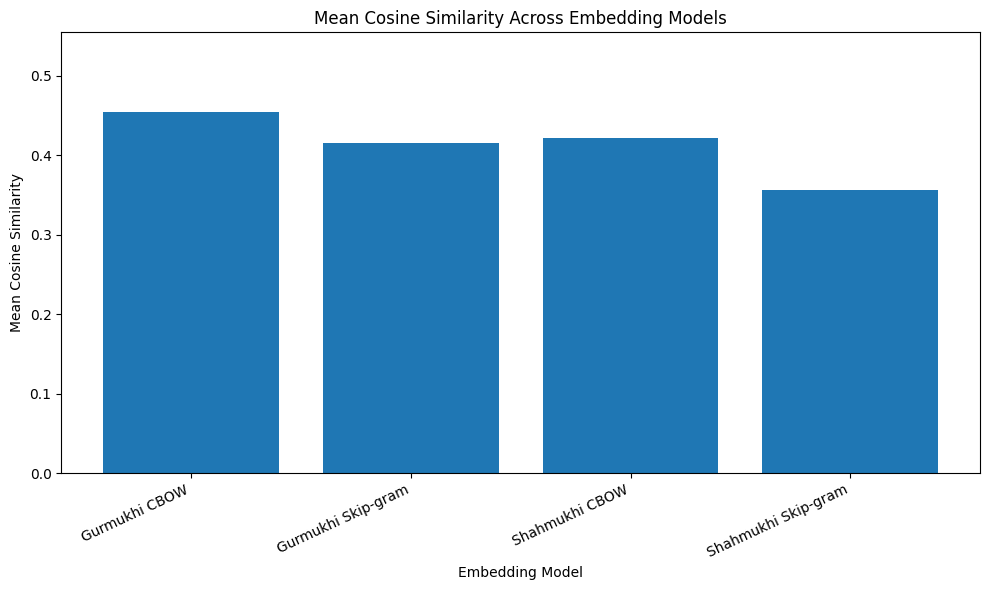

✅ Figure saved to: /content/intrinsic_evaluation_results/mean_cosine_similarity_comparison.png


In [172]:
# ============================================
# Cell 28: Cosine Similarity Comparison
# ============================================

import matplotlib.pyplot as plt

plot_data = final_results.copy()
plot_data["Label"] = (
    plot_data["Script"] + " " + plot_data["Architecture"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["Label"],
    plot_data["Mean_Cosine_Similarity"]
)

plt.title("Mean Cosine Similarity Across Embedding Models")
plt.xlabel("Embedding Model")
plt.ylabel("Mean Cosine Similarity")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(plot_data["Mean_Cosine_Similarity"]) + 0.1)
plt.tight_layout()

cosine_plot_path = (
    f"{RESULTS_DIR}/mean_cosine_similarity_comparison.png"
)

plt.savefig(
    cosine_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Figure saved to: {cosine_plot_path}")

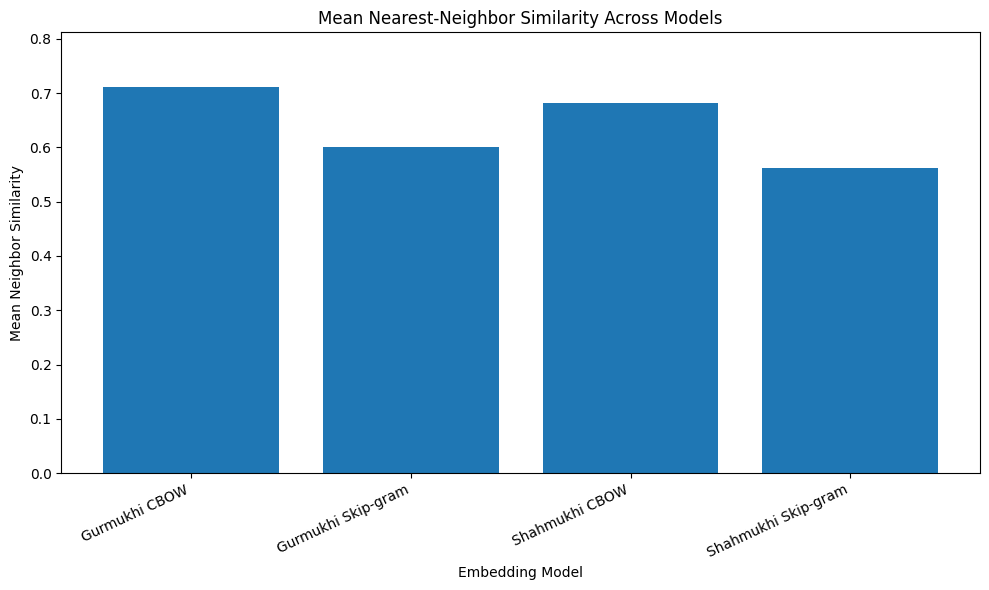

✅ Figure saved to: /content/intrinsic_evaluation_results/mean_neighbor_similarity_comparison.png


In [173]:
# ============================================
# Cell 29: Nearest-Neighbor Comparison
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["Label"],
    plot_data["Mean_Neighbor_Similarity"]
)

plt.title("Mean Nearest-Neighbor Similarity Across Models")
plt.xlabel("Embedding Model")
plt.ylabel("Mean Neighbor Similarity")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(plot_data["Mean_Neighbor_Similarity"]) + 0.1)
plt.tight_layout()

neighbor_plot_path = (
    f"{RESULTS_DIR}/mean_neighbor_similarity_comparison.png"
)

plt.savefig(
    neighbor_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Figure saved to: {neighbor_plot_path}")

In [174]:
# ============================================
# Cell 30: Best-Performing Models
# ============================================

best_cosine_model = final_results.loc[
    final_results["Mean_Cosine_Similarity"].idxmax()
]

best_neighbor_model = final_results.loc[
    final_results["Mean_Neighbor_Similarity"].idxmax()
]

print("=" * 60)
print("Best Model by Mean Cosine Similarity")
print("=" * 60)
print(f"Model: {best_cosine_model['Model']}")
print(
    f"Score: "
    f"{best_cosine_model['Mean_Cosine_Similarity']:.4f}"
)

print("\n" + "=" * 60)
print("Best Model by Mean Nearest-Neighbor Similarity")
print("=" * 60)
print(f"Model: {best_neighbor_model['Model']}")
print(
    f"Score: "
    f"{best_neighbor_model['Mean_Neighbor_Similarity']:.4f}"
)

Best Model by Mean Cosine Similarity
Model: Gurmukhi CBOW
Score: 0.4545

Best Model by Mean Nearest-Neighbor Similarity
Model: Gurmukhi CBOW
Score: 0.7119


In [175]:
# ============================================
# Cell 31: Paper-Ready Results Table
# ============================================

paper_results = final_results[
    [
        "Model",
        "Vocabulary Size",
        "Mean_Cosine_Similarity",
        "Mean_Neighbor_Similarity"
    ]
].copy()

paper_results = paper_results.rename(
    columns={
        "Vocabulary Size": "Vocabulary",
        "Mean_Cosine_Similarity": "Mean Cosine Similarity",
        "Mean_Neighbor_Similarity": "Mean Neighbor Similarity"
    }
)

paper_results["Mean Cosine Similarity"] = (
    paper_results["Mean Cosine Similarity"].round(4)
)

paper_results["Mean Neighbor Similarity"] = (
    paper_results["Mean Neighbor Similarity"].round(4)
)

paper_results = paper_results.sort_values(
    by="Mean Cosine Similarity",
    ascending=False
).reset_index(drop=True)

display(paper_results)

,Model,Vocabulary,Mean Cosine Similarity,Mean Neighbor Similarity
0,Gurmukhi CBOW,6349,0.4545,0.7119
1,Shahmukhi CBOW,6748,0.4218,0.6823
2,Gurmukhi Skip-gram,5205,0.4156,0.6013
3,Shahmukhi Skip-gram,6748,0.3561,0.5614


In [176]:
# ============================================
# Cell 32: Save Paper-Ready Table
# ============================================

paper_results.to_csv(
    f"{RESULTS_DIR}/paper_ready_intrinsic_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Paper-ready intrinsic results table saved.")

✅ Paper-ready intrinsic results table saved.
